<a href="https://colab.research.google.com/github/Samueltiago/Mapa-da-violencia/blob/main/PCGViolenciaCodigo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# -*- coding: utf-8 -*-
"""AnalisePCG - PIBxViolencia

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1U1HM2TFujpIDOCq1wO1GSS0hzrK4nEpB
"""


'AnalisePCG - PIBxViolencia\n\nAutomatically generated by Colab.\n\nOriginal file is located at\n    https://colab.research.google.com/drive/1U1HM2TFujpIDOCq1wO1GSS0hzrK4nEpB\n'

In [2]:
import pandas as pd

In [3]:
dados_tratados_2015 = "/content/drive/MyDrive/Faculdade /3 Semestre/EstudoEstruturaDeDados/PCG-3o-Semestre---Mapa-da-Violencia/dados_tratados_2015.csv"
dados_tratados_2016 = "/content/drive/MyDrive/Faculdade /3 Semestre/EstudoEstruturaDeDados/PCG-3o-Semestre---Mapa-da-Violencia/dados_tratados_2016.csv"
dados_tratados_2017 = "/content/drive/MyDrive/Faculdade /3 Semestre/EstudoEstruturaDeDados/PCG-3o-Semestre---Mapa-da-Violencia/dados_tratados_2017.csv"
dados_tratados_2018 = "/content/drive/MyDrive/Faculdade /3 Semestre/EstudoEstruturaDeDados/PCG-3o-Semestre---Mapa-da-Violencia/dados_tratados_2018.csv"
dados_tratados_2019 = "/content/drive/MyDrive/Faculdade /3 Semestre/EstudoEstruturaDeDados/PCG-3o-Semestre---Mapa-da-Violencia/dados_tratados_2019.csv"
dados_tratados_2020 = "/content/drive/MyDrive/Faculdade /3 Semestre/EstudoEstruturaDeDados/PCG-3o-Semestre---Mapa-da-Violencia/dados_tratados_2020.csv"

In [4]:
# Lendo os arquivos CSV
df_2015 = pd.read_csv(dados_tratados_2015)
df_2016 = pd.read_csv(dados_tratados_2016)
df_2017 = pd.read_csv(dados_tratados_2017)
df_2018 = pd.read_csv(dados_tratados_2018)
df_2019 = pd.read_csv(dados_tratados_2019)
df_2020 = pd.read_csv(dados_tratados_2020)

In [5]:
# Empilhando todos os anos em um único DataFrame
df_total = pd.concat([df_2015, df_2016, df_2017, df_2018, df_2019, df_2020], ignore_index=True)

# ---------------------------------------------------------
# CORREÇÃO E NORMALIZAÇÃO DO PIB
# ---------------------------------------------------------
if df_total['PIB'].dtype == 'object':
    df_total['PIB'] = df_total['PIB'].str.replace(r'R\$\s*', '', regex=True)
    df_total['PIB'] = df_total['PIB'].str.replace('.', '', regex=False)
    df_total['PIB'] = df_total['PIB'].str.replace(',', '.', regex=False)
    df_total['PIB'] = df_total['PIB'].astype(float)

#Um erro de formatação causou com que o PIB ficasse em quadrilhões; aqui corrigimos para bilhões
df_total.loc[df_total['PIB'] > 1e12, 'PIB'] = df_total['PIB'] / 1e9

df_total['PIB_Bilhoes'] = (df_total['PIB'] * 1000) / 1e9
df_total['PIB_Bilhoes'] = df_total['PIB_Bilhoes'].round(2)

print(df_total.head())

              municipio  total_vitima  total           PIB   ano  PIB_Bilhoes
0             AMERICANA          77.0  272.0  1.010173e+07  2015        10.10
1              ANÁPOLIS          20.0    0.0  1.330150e+07  2015        13.30
2  APARECIDA DE GOIÂNIA           7.0    0.0  1.151867e+07  2015        11.52
3               ARACAJU         564.0    0.0  1.567268e+07  2015        15.67
4             ARAUCÁRIA           5.0    0.0  1.395225e+07  2015        13.95


In [6]:
# Resumo estatístico (Média, Desvio Padrão, Mínimo e Máximo)
print(df_total[['total_vitima', 'PIB_Bilhoes']].describe())


       total_vitima  PIB_Bilhoes
count    600.000000   600.000000
mean     520.038333    37.481800
std      896.819826    79.965969
min        0.000000     8.530000
25%      127.000000    13.300000
50%      255.000000    18.470000
75%      564.000000    30.640000
max     8116.000000   763.810000


In [7]:
# Mediana (importante para comparar com a média)
print("Mediana de Vítimas:", df_total['total_vitima'].median())
print("Mediana do PIB:", df_total['PIB_Bilhoes'].median())

Mediana de Vítimas: 255.0
Mediana do PIB: 18.47


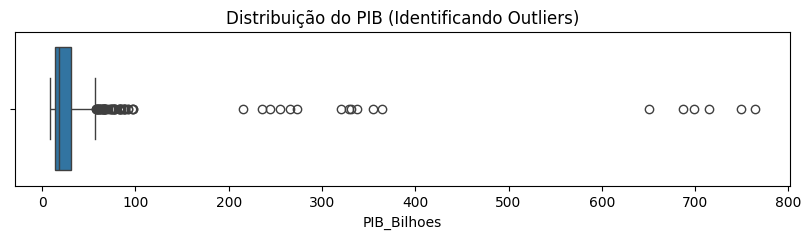

In [8]:
# Plotando gráfico de outliers
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 2))
sns.boxplot(x=df_total['PIB_Bilhoes'])
plt.title('Distribuição do PIB (Identificando Outliers)')
plt.show()


In [9]:
import plotly.express as px

#gráfico scatter
fig = px.scatter(
    df_total,
    x='PIB_Bilhoes',
    y='total_vitima',
    color='ano',
    hover_data=['municipio'],
    title='Relação entre PIB (em Bilhões) e Total de Vítimas',
    labels={'PIB_Bilhoes': 'PIB do Município', 'total_vitima': 'Total de Vítimas'},
    width=800,   # Define a largura
    height=500   # Define a altura
)

fig.show()

In [10]:
#Histograma para verificar a concentração dos casos de violência
fig_hist = px.histogram(
    df_total,
    x='total_vitima',
    nbins=30,
    title='Frequência da Quantidade de Vítimas (Concentração do Problema)',
    labels={'total_vitima': 'Total de Vítimas'},
    width=800,   # Define a largura
    height=500   # Define a altura
)
fig_hist.show()